<a href="https://colab.research.google.com/github/obaid147/titanic-ml-project/blob/main/titanic_survival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
# Load the Titanic dataset directly from a public URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# checking for missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
# Fill missing Age with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop the Cabin column (too many missing values)
df = df.drop(columns=['Cabin'])

# Fill missing Embarked with the most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Confirm no more missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
"""Next step: our model can only understand numbers, but a few of our
columns are still text — Sex and Embarked.
We need to convert these to numeric form. This is called encoding.""";
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

# Convert 'Embarked' into numeric using one-hot encoding

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)


In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


Selecting our features and separating the data into X (inputs the model learns from) and y (the target we're trying to predict — Survived).

In [7]:
# Drop columns that aren't useful for prediction
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [8]:
# Separate features (X) and target (y)
X = df.drop(columns=['Survived'])
y = df['Survived']

In [9]:
# Check the shapes. Number of passangers and features
print(X.shape)
print(y.shape)

(891, 8)
(891,)


In [10]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#it just makes the split reproducible (same random split every time you run it), so your results are consistent across runs. The number 42 is arbitrary — a common convention, not special.

In [11]:
print(X_train.shape)
print(X_test.shape)

(712, 8)
(179, 8)


In [12]:
# let's train our first model — logistic regression,
from sklearn.linear_model import LogisticRegression

# Create and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [13]:
# Make predictions on the test set and check accuracy.
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)
# model.predict(X_test) the model looks at the 179 passengers it's never seen before and guesses survived/not survived for each.

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
# compares those guesses to the real answers (y_test) and gives the percentage it got right.
print(f"Accuracy: {accuracy}")

Accuracy: 0.8100558659217877


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

"""
Predicted: Died	Predicted: Survived
Actual: Died	90 ✅ (correct)	15 ❌ (wrongly said survived)
Actual: Survived	19 ❌ (wrongly said died)	55 ✅ (correct)
""";
"""
model is slightly better at spotting "died" (0.84 F1) than "survived" (0.76 F1)
likely because there were more "died" examples to learn from (105 vs 74).
This is a completely normal, healthy result for a first pass.
""";

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



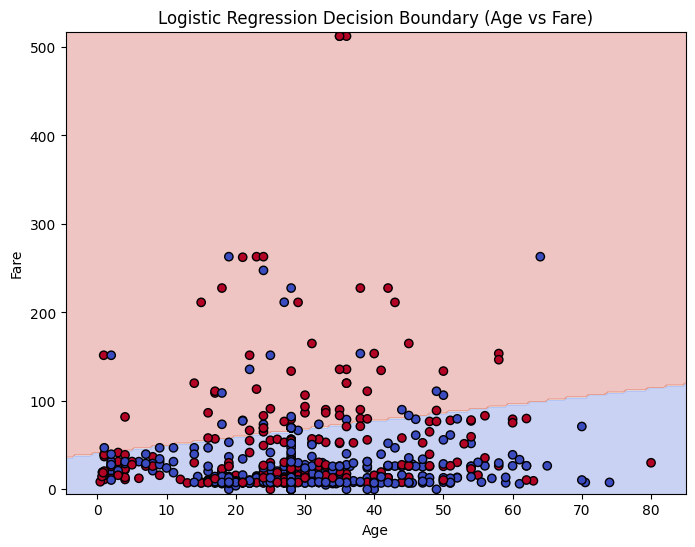

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# For visualization, use just 2 features: Age and Fare
X_vis = X_train[['Age', 'Fare']].values
y_vis = y_train.values

# Train a simple logistic regression on just these 2 features
vis_model = LogisticRegression()
vis_model.fit(X_vis, y_vis)

# Create a grid of points covering the feature space
x_min, x_max = X_vis[:, 0].min() - 5, X_vis[:, 0].max() + 5
y_min, y_max = X_vis[:, 1].min() - 5, X_vis[:, 1].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Predict for every point in the grid
Z = vis_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the actual data points
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='coolwarm', edgecolors='k')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Logistic Regression Decision Boundary (Age vs Fare)')
plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict and check accuracy
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

Random Forest Accuracy: 0.80


**Tensorflow**

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
"""features have very different scales (Age ~0-80, Fare ~0-500). This
messes up gradient descent for neural nets.
Scaling fixes it so training goes smoother.""";

Scaling done!


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the model
tf_model = Sequential([
    Dense(units=16, activation='relu'),
    Dense(units=8, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

# compile: Specify how the model learns
tf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
tf_model.fit(X_train_scaled, y_train, epochs=100, verbose=0)

In [23]:
tf_pred = (tf_model.predict(X_test_scaled) > 0.5).astype(int)
tf_accuracy = accuracy_score(y_test, tf_pred)
print(f"Tensorflow Accuracy: {tf_accuracy:.2f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Tensorflow Accuracy: 0.82
